# Excercise 2a: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [3]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

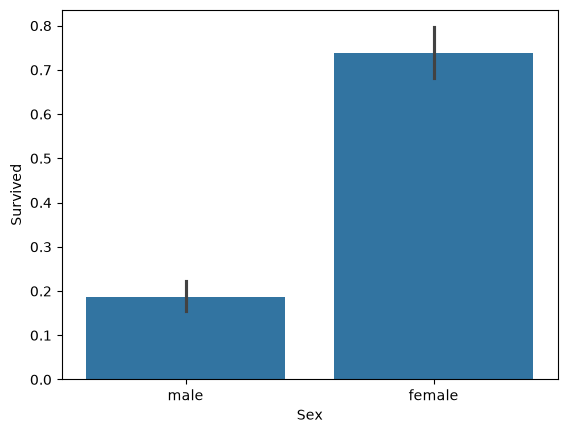

In [4]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes. In the training data, first-class passengers had the highest survival rate: 60.7% (99 of 163), compared with 48.3% (73 of 151) in second class and 24.1% (96 of 398) in third class. This is an association; the comparison alone does not establish that ticket class caused the difference.

        passengers  survivors  survival_rate
Pclass                                      
1              163         99          0.607
2              151         73          0.483
3              398         96          0.241


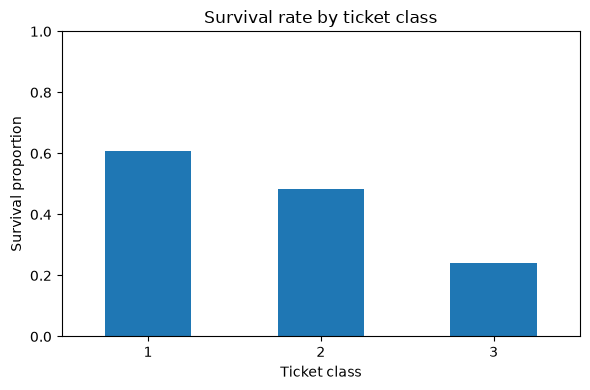

In [5]:
# Survival rates and group sizes by ticket class (training data only)
class_summary = data.groupby('Pclass')['Survived'].agg(
    passengers='count', survivors='sum', survival_rate='mean'
)
print(class_summary.to_string(float_format=lambda value: f'{value:.3f}'))

ax = class_summary['survival_rate'].plot.bar(rot=0, figsize=(6, 4))
ax.set(title='Survival rate by ticket class', xlabel='Ticket class',
       ylabel='Survival proportion', ylim=(0, 1))
plt.tight_layout()
plt.show()

# Question 2: Is survival related to Embarked?

Answer: Yes. Passengers boarding at Cherbourg had the highest survival rate (54.4%), followed by Queenstown (36.7%) and Southampton (33.5%). This shows an association between embarkation port and survival, but differences in ticket class and sex may also contribute.

          passengers  survivors  survival_rate
Embarked                                      
C                125         68          0.544
Q                 60         22          0.367
S                525        176          0.335
Missing            2          2          1.000


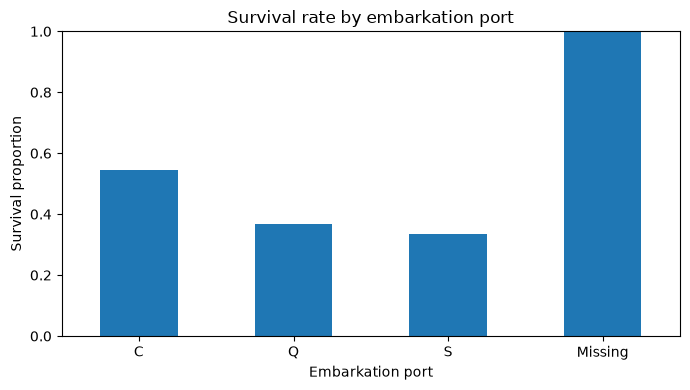

In [6]:
# Keep missing embarkation information visible as a separate group.
embarked_summary = (
    data.assign(Embarked=data['Embarked'].fillna('Missing'))
    .groupby('Embarked')['Survived']
    .agg(passengers='count', survivors='sum', survival_rate='mean')
    .reindex(['C', 'Q', 'S', 'Missing'])
)
print(embarked_summary.to_string(float_format=lambda value: f'{value:.3f}'))

ax = embarked_summary['survival_rate'].plot.bar(rot=0, figsize=(7, 4))
ax.set(title='Survival rate by embarkation port', xlabel='Embarkation port',
       ylabel='Survival proportion', ylim=(0, 1))
plt.tight_layout()
plt.show()

# Question 3: How is age related to survival?

Answer: Children under 13 had the highest observed survival rate (56.9%), but survival did not decrease steadily with age: passengers aged 35 to under 60 had a higher rate (41.5%) than those aged 18 to under 35 (36.8%). Age was missing for 140 passengers, which limits the comparison.

           passengers  survivors  survival_rate
AgeGroup                                       
0 to <13           58         33          0.569
13 to <18          33         15          0.455
18 to <35         299        110          0.368
35 to <60         164         68          0.415
60+                18          6          0.333
Missing           140         36          0.257
Missing ages: 140 of 712 passengers


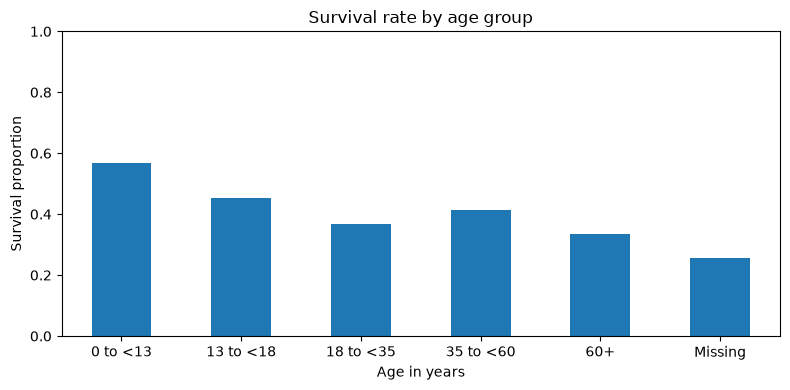

In [7]:
# Left-inclusive age groups: [0, 13), [13, 18), [18, 35), [35, 60), [60, infinity).
age_labels = ['0 to <13', '13 to <18', '18 to <35', '35 to <60', '60+']
age_group = pd.cut(
    data['Age'], bins=[0, 13, 18, 35, 60, np.inf],
    labels=age_labels, right=False
)
age_group = age_group.cat.add_categories(['Missing']).fillna('Missing')
age_summary = (
    data.assign(AgeGroup=age_group)
    .groupby('AgeGroup', observed=False)['Survived']
    .agg(passengers='count', survivors='sum', survival_rate='mean')
)
print(age_summary.to_string(float_format=lambda value: f'{value:.3f}'))
print(f"Missing ages: {data['Age'].isna().sum()} of {len(data)} passengers")

ax = age_summary['survival_rate'].plot.bar(rot=0, figsize=(8, 4))
ax.set(title='Survival rate by age group', xlabel='Age in years',
       ylabel='Survival proportion', ylim=(0, 1))
plt.tight_layout()
plt.show()

# Question 4: Does family size somehow affect the survival rate?

Answer: Yes. Small families of 2-4 people had the highest survival rate (55.6%), compared with passengers travelling alone (30.5%) and families of 5 or more (15.7%). Family size includes the passenger. This shows an association, although differences in age, sex and ticket class may also contribute.

             passengers  survivors  survival_rate
FamilyGroup                                      
Alone (1)           429        131          0.305
Small (2-4)         232        129          0.556
Large (5+)           51          8          0.157


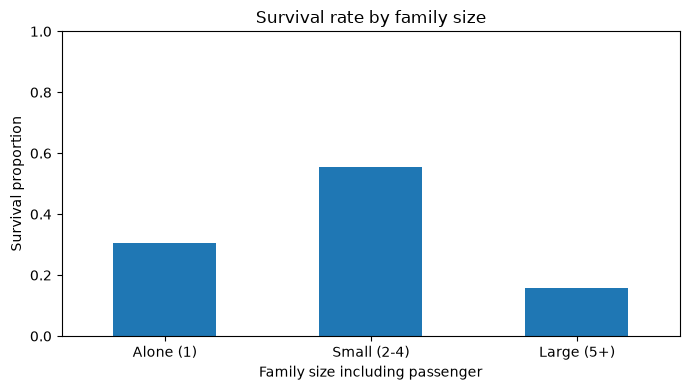

In [8]:
# Family size includes the passenger, siblings/spouse and parents/children.
family_data = data.assign(FamilySize=data['SibSp'] + data['Parch'] + 1)
family_data['FamilyGroup'] = pd.cut(
    family_data['FamilySize'], bins=[0, 1, 4, np.inf],
    labels=['Alone (1)', 'Small (2-4)', 'Large (5+)']
)
family_summary = (
    family_data.groupby('FamilyGroup', observed=False)['Survived']
    .agg(passengers='count', survivors='sum', survival_rate='mean')
)
print(family_summary.to_string(float_format=lambda value: f'{value:.3f}'))

ax = family_summary['survival_rate'].plot.bar(rot=0, figsize=(7, 4))
ax.set(title='Survival rate by family size', xlabel='Family size including passenger',
       ylabel='Survival proportion', ylim=(0, 1))
plt.tight_layout()
plt.show()

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Yes. Among common titles, Mrs had the highest survival rate (83.3%), followed by Miss (66.4%), Master (54.5%) and Mr (15.5%). Titles reflect characteristics such as sex and age that may help explain these differences. Rare titles had too few passengers to support firm conclusions.

              passengers  survivors  survival_rate
Title                                             
Mr                   419         65          0.155
Miss                 143         95          0.664
Mrs                   96         80          0.833
Master                33         18          0.545
Rev                    5          0          0.000
Dr                     5          2          0.400
Mlle                   2          2          1.000
Major                  2          1          0.500
Col                    2          1          0.500
Capt                   1          0          0.000
Lady                   1          1          1.000
Mme                    1          1          1.000
Ms                     1          1          1.000
the Countess           1          1          1.000


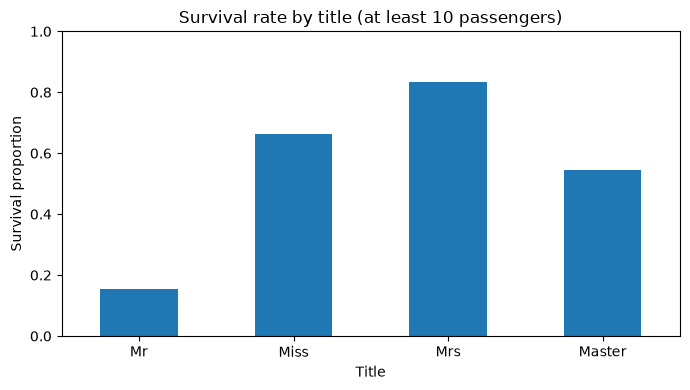

In [9]:
# Extract the title between the comma and the following period in each name.
title_data = data.assign(
    Title=data['Name'].str.extract(r',\s*([^.]*)\.', expand=False)
        .str.strip().fillna('Unknown')
)
title_summary = (
    title_data.groupby('Title')['Survived']
    .agg(passengers='count', survivors='sum', survival_rate='mean')
    .sort_values('passengers', ascending=False)
)
print(title_summary.to_string(float_format=lambda value: f'{value:.3f}'))

# Show common titles in the chart; keep rare titles visible in the table.
common_titles = title_summary.loc[title_summary['passengers'] >= 10]
ax = common_titles['survival_rate'].plot.bar(rot=0, figsize=(7, 4))
ax.set(title='Survival rate by title (at least 10 passengers)', xlabel='Title',
       ylabel='Survival proportion', ylim=(0, 1))
plt.tight_layout()
plt.show()